### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [3]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [4]:
missing = data.isnull().sum()
print(missing)


destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64


3. Decide what to do about your missing data -- drop, replace, other...

In [5]:
data = data.drop(columns=['car'])
data = data.dropna()

4. What proportion of the total observations chose to accept the coupon?



In [6]:
acceptance_rate = data['Y'].mean()
acceptance_rate

np.float64(0.5693352098683666)

5. Use a bar plot to visualize the `coupon` column.

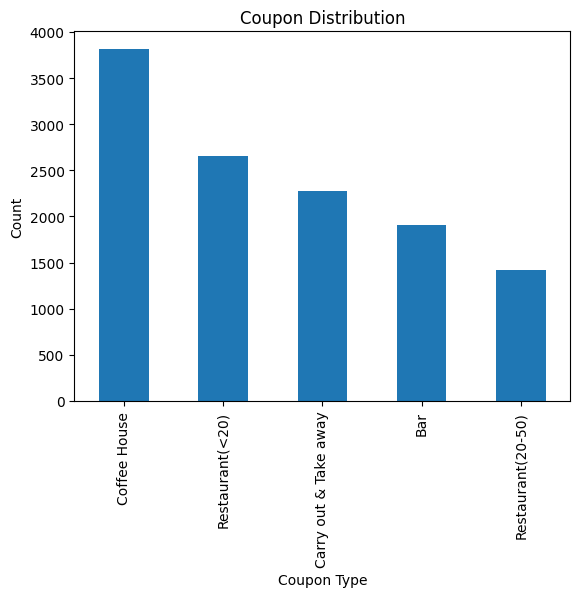

In [7]:
data['coupon'].value_counts().plot(kind='bar')
plt.title('Coupon Distribution')
plt.xlabel('Coupon Type')
plt.ylabel('Count')

plt.show()

6. Use a histogram to visualize the temperature column.

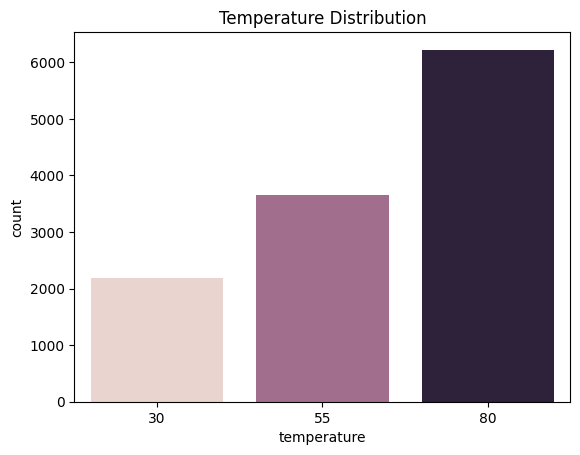

In [8]:
sns.countplot(data, x='temperature', hue='temperature',legend=False)
plt.title('Temperature Distribution')

plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [9]:
bar_coupons = data[data['coupon'] == 'Bar']

2. What proportion of bar coupons were accepted?


In [10]:
bar_accept_rate = bar_coupons['Y'].mean()
print(bar_accept_rate)

0.41191845269210664


About ~41% of the bar coupons were accepted.

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [11]:
bar_3_or_fewer = bar_coupons[
    bar_coupons['Bar'].isin(['never', 'less1', '1~3'])
]['Y'].mean()
bar_more_than_3 = bar_coupons[
    bar_coupons['Bar'].isin(['4~8', 'gt8'])
]['Y'].mean()

print(bar_3_or_fewer)
print(bar_more_than_3)

0.37267441860465117
0.7616580310880829


We can see that drivers who visited the bar 3 or fewer times per month accepted the coupon ~37% of the time, compared to ~76% for those who visited more than 3 times

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [12]:
bar_coupons['age'].value_counts()

age
21         397
26         368
31         324
50plus     273
36         196
41         171
46         103
below21     81
Name: count, dtype: int64

In [13]:
group1 = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3','4~8', 'gt8']))
    & (bar_coupons['age'] != 'below21') 
    & (bar_coupons['age'] != '21')
]['Y'].mean()
group2 = bar_coupons[~
    ((bar_coupons['Bar'].isin(['1~3','4~8', 'gt8'])) 
    & (bar_coupons['age'] != 'below21') 
    & (bar_coupons['age'] != '21'))
]['Y'].mean()

print(f"Group 1: {group1:.2%}")
print(f"Group 2: {group2:.2%}")

Group 1: 68.98%
Group 2: 33.77%


We can see that drivers who go to a bar more than once a month and are over the age of 25 have an acceptance rate of ~69%, and all others have an acceptance rate of 34%. There is a clear difference between the two.

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [14]:
bar_coupons['occupation'].unique()

<StringArray>
[               'Architecture & Engineering',
                                   'Student',
                'Education&Training&Library',
                                'Unemployed',
                        'Healthcare Support',
      'Healthcare Practitioners & Technical',
                           'Sales & Related',
                                'Management',
  'Arts Design Entertainment Sports & Media',
                   'Computer & Mathematical',
              'Life Physical Social Science',
                   'Personal Care & Service',
           'Office & Administrative Support',
                 'Construction & Extraction',
                                     'Legal',
                                   'Retired',
               'Community & Social Services',
         'Installation Maintenance & Repair',
          'Transportation & Material Moving',
                      'Business & Financial',
                        'Protective Service',
        'Food Prepar

In [15]:
group1 = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['passanger'] != 'Kid(s)') &
    (bar_coupons['occupation'] != 'Farming Fishing & Forestry')
]['Y'].mean()

group2 = bar_coupons[~(
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['passanger'] != 'Kid(s)') &
    (bar_coupons['occupation'] != 'Farming Fishing & Forestry')
)]['Y'].mean()

print(f"Group 1: {group1:.2%}")
print(f"Group 2: {group2:.2%}")

Group 1: 70.94%
Group 2: 29.79%


Drivers who went to a bar more than once a month, had passengers that were not kids, and worked outside of farming, fishing, or forestry had an acceptance rate of ~70%, compared to ~30% for all others

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [16]:
bar_coupons['income'].unique()

<StringArray>
[ '$62500 - $74999',  '$12500 - $24999',  '$75000 - $87499',
  '$50000 - $62499',  '$37500 - $49999',  '$25000 - $37499',
  '$100000 or More',  '$87500 - $99999', 'Less than $12500']
Length: 9, dtype: str

In [17]:
group1 = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['passanger'] != 'Kid(s)') &
    (bar_coupons['maritalStatus'] != 'Widowed')
]['Y'].mean()

group2 = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['age'].isin(['below21', '21', '26']))
]['Y'].mean()

group3 = bar_coupons[
    (bar_coupons['RestaurantLessThan20'].isin(['4~8', 'gt8'])) &
    (bar_coupons['income'].isin(['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']))
]['Y'].mean()

print(f"Group 1: {group1:.2%}")
print(f"Group 2: {group2:.2%}")
print(f"Group 3: {group3:.2%}")

Group 1: 70.94%
Group 2: 71.95%
Group 3: 45.65%


Drivers who go to the bar more than once a month, do not have passengers that are kids, and are not widowed tend to accept the coupon about ~71% of the time.
Drivers that go to the bar more than once a month and are below 30 years old accept the coupon ~72% of the time.
Drivers that go to cheap restaurants more than 4 times a month with an income lower than $50,000 accept the coupon ~46% of the time.

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Based on the observations we've looked at, we can hypothesize that drivers who accept the bar coupons tend to be frequent bar-goers who do not have kid passengers. This makes sense in the context of it being a bar coupon, as having a kid passenger would deter people from going to the bar in the first place. Age also seems to play a part in whether drivers accept coupons or not, as those who are older than 25 seem to accept the coupon more often than those under 25. The data suggests that coupon acceptance rate depends on a combination of age, who their passengers are, and how often drivers already frequent bars.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

I chose to analyze the group of drivers who accept the Carry out & Take Out coupons. 

In [25]:
# reforming dataset & calculating coupon acceptance rate
carryout_coupons = data[data['coupon'] == 'Carry out & Take away']
carryout_acceptance_rate = carryout_coupons['Y'].mean()

print(f"Carry out acceptance rate: {carryout_acceptance_rate:.2%}")

Carry out acceptance rate: 73.77%


Carry out coupons have a notably high overall acceptance rate of ~74%.

In [19]:
# % who order carry out frequently (4 or more times a month)
group1 = carryout_coupons[
    carryout_coupons['CarryAway'].isin(['4~8', 'gt8'])
    ]['Y'].mean()

# % who order carry out less frequently (3 or less times a month)
group2 = carryout_coupons[
    carryout_coupons['CarryAway'].isin(['never', 'less1', '1~3'])
    ]['Y'].mean()

print(f"Group 1: {group1:.2%}")
print(f"Group 2: {group2:.2%}")

Group 1: 75.35%
Group 2: 72.36%


Looking at the acceptance rates for people who get takeout more than once a month compared to those who get it less, we can see that these percetanges don't differ too much, with it being ~75% and ~72% respectively. This means that the amount of times people order carry out may not affect the coupon acceptance rate too heavily.

We can also take this a step further and compare the differences in percentages with the amount of drivers that accepted the bar coupon. Looking back, we saw that there was about a ~39% gap between those who frequent bars regularly versus those who don't. For carryout, there is only a ~3% gap. This supports our conclusion that frequency of carry out does not affect proportion of coupon acceptance.

In [20]:
# % heading home at 6PM (evening commute)
group1 = carryout_coupons[
    (carryout_coupons['time'] == '6PM') &
    (carryout_coupons['destination'] == 'Home')
]['Y'].mean()

# % heading to work at 7AM (morning commute)
group2 = carryout_coupons[
    (carryout_coupons['time'] == '7AM') &
    (carryout_coupons['destination'] == 'Work')
]['Y'].mean()

print(f"Group 1: {group1:.2%}")
print(f"Group 2: {group2:.2%}")

Group 1: 81.59%
Group 2: 66.12%


Looking at the acceptance rates for drivers heading home at 6PM compared to those heading to work at 7AM, we can see that there is a noticeable difference of ~16%, with drivers heading home accepting the coupon ~82% of the time compared to ~66% for those heading to work. This makes intuitive sense, as drivers heading home after a long day may be more inclined to pick up takeout rather than cook, while those heading to work in the morning may be less focused on finding food. This suggests that time of day and destination together play a role in whether drivers accept carry out coupons.

In [21]:
# % heading home at 6PM with a partner in the car
group1 = carryout_coupons[
    (carryout_coupons['time'] == '6PM') &
    (carryout_coupons['destination'] == 'Home') &
    (carryout_coupons['passanger'] == 'Partner')
]['Y'].mean()

# % heading home at 6PM alone
group2 = carryout_coupons[
    (carryout_coupons['time'] == '6PM') &
    (carryout_coupons['destination'] == 'Home') &
    (carryout_coupons['passanger'] == 'Alone')
]['Y'].mean()

print(f"Group 1: {group1:.2%}")
print(f"Group 2: {group2:.2%}")

Group 1: 77.78%
Group 2: 81.90%


Drivers heading home at 6PM showed high acceptance rates regardless of passenger type, with those traveling alone accepting the coupon ~82% of the time compared to ~78% for those with a partner in the car. The small ~4% difference suggests that passenger type does not heavily influence coupon acceptance when the time and destination are already favorable. 

Finally, let's look at how weather affects the acceptance rate. We can start by looking at a barplot.


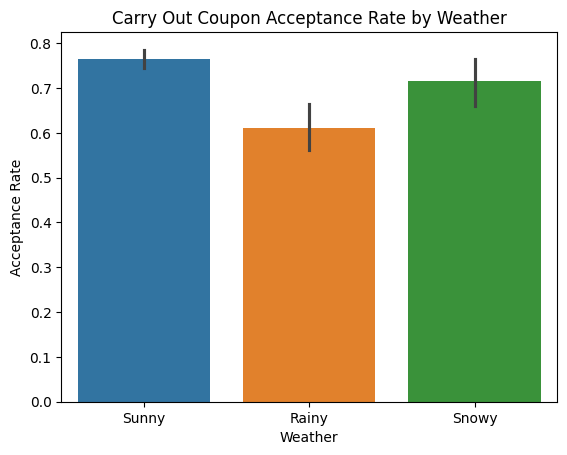

In [22]:
sns.barplot(data=carryout_coupons, x='weather', y='Y', hue='weather', legend=False)
plt.title('Carry Out Coupon Acceptance Rate by Weather')
plt.xlabel('Weather')
plt.ylabel('Acceptance Rate')
plt.show()

In [23]:
# looking into the barplot further...
weather_acceptance = carryout_coupons.groupby('weather')['Y'].mean()
print(weather_acceptance)

weather
Rainy    0.611296
Snowy    0.715753
Sunny    0.764078
Name: Y, dtype: float64


Analyzing acceptance rates by weather, sunny weather had the highest acceptance rate at ~76%, followed by snowy weather at ~72%, and rainy weather at ~61%. Interestingly, rainy weather had the lowest acceptance rate despite the intuitive expectation that bad weather would make drivers more likely to pick up takeout rather than cook at home. This suggests that rainy weather may deter drivers from making detours altogether, regardless of the coupon type.

With all of this information, let's try to predict which combination of factors will give us the highest % for most likely to accept the coupon and the lowest % for least likely to accept the coupon.

In [24]:
# most likely: drivers heading home at 6PM on a sunny day with a partner or alone
most_likely = carryout_coupons[
    (carryout_coupons['time'] == '6PM') &
    (carryout_coupons['destination'] == 'Home') &
    (carryout_coupons['weather'] == 'Sunny') &
    (carryout_coupons['passanger'].isin(['Alone', 'Partner']))
]['Y'].mean()

# least likely: drivers heading to work at 7AM on a rainy day
least_likely = carryout_coupons[
    (carryout_coupons['time'] == '7AM') &
    (carryout_coupons['destination'] == 'Work') &
    (carryout_coupons['weather'] == 'Rainy')
]['Y'].mean()

print(f"Most likely: {most_likely:.2%}")
print(f"Least likely: {least_likely:.2%}")

Most likely: 81.90%
Least likely: 50.00%


Based on the factors explored in this analysis, we can predict that the most likely driver to accept a carry out coupon is someone driving home alone on a sunny evening, with an acceptance rate of ~82%. On the other hand, the least likely driver to accept is someone heading to work on a rainy morning with kids in the car, with an acceptance rate of ~50%. Interestingly, even the least likely profile still has a half chance of accepting the coupon, which reflects the overall popularity of carry out coupons across all groups. This suggests that while contextual factors like time, destination, weather, and passenger type do influence acceptance rates, carry out coupons are generally well received regardless of the situation.

If I were to recommend something to businesses handing out coupons, I would say that the best time to send carry out coupons appears to be around 6PM, when drivers are heading home after work and are most likely to pick up food on the way. Sunny weather also seems to work in favor of coupon acceptance, so targeting drivers on clear days could improve results. As far as next steps go, it would be worthwhile to explore how income and age interact with the factors identified here, as these were not deeply analyzed in this study. 